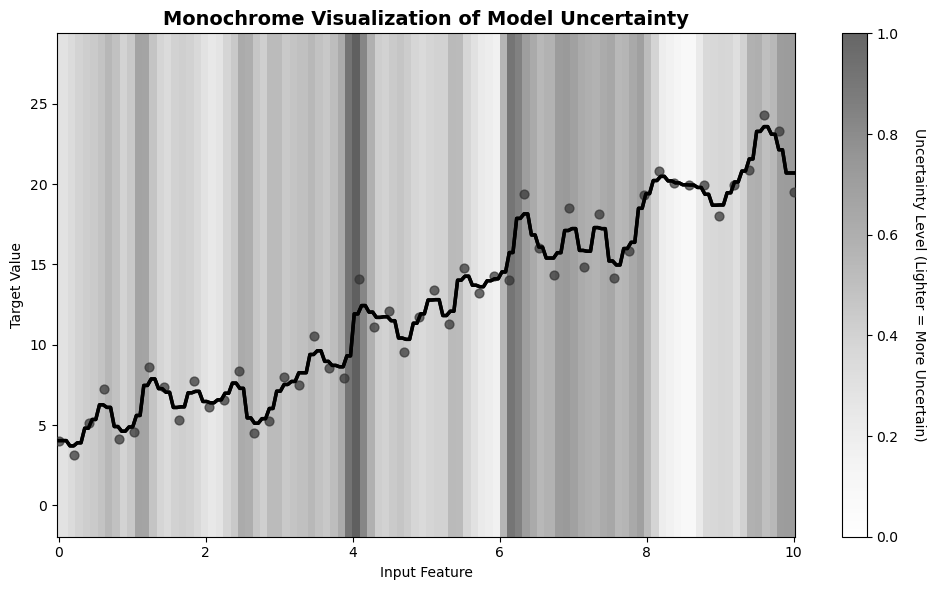

Monochrome chart saved as 'monochrome_uncertainty.png'


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# --- 1. Data Generation (Same as before) ---
np.random.seed(42)
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 2 * X.flatten() + 3 + np.random.normal(0, 2, 50)

# Test points for smooth visualization
X_test = np.linspace(0, 10, 200).reshape(-1, 1)

# --- 2. Model Training & Uncertainty Estimation ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Get predictions from all trees to estimate variance
uncertainty_samples = np.array([tree.predict(X_test) for tree in model.estimators_])
mean_pred = np.mean(uncertainty_samples, axis=0)
std_uncertainty = np.std(uncertainty_samples, axis=0)

# Normalize uncertainty for visualization (0 to 1)
# We invert it so high uncertainty = light gray (closer to 1.0 in grayscale)
# Or keep direct: high uncertainty = darker? Let's go with: 
# High Uncertainty = Lighter Gray (White = Max Uncertainty, Black = Certainty)
uncertainty_normalized = (std_uncertainty - std_uncertainty.min()) / (std_uncertainty.max() - std_uncertainty.min())

# --- 3. Monochrome Visualization ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the mean prediction as a solid black line
ax.plot(X_test, mean_pred, color='black', linewidth=2.5, label='Mean Prediction')

# Scatter original data in dark gray
ax.scatter(X, y, color='#333333', alpha=0.7, s=40, label='Observed Data', zorder=3)

# Create a background gradient representing uncertainty
# We use a 'Greys' colormap where 0 is white and 1 is black.
# To make high uncertainty stand out, we might want high uncertainty to be lighter (white-ish)
# Let's map: Low Uncertainty -> Dark Gray, High Uncertainty -> Light Gray/White
# Using 'binary_r' (reversed binary) gives White=High, Black=Low
# But standard 'Greys' is Black=Low, White=High. Let's use 'Greys_r' (Reversed) 
# Actually, let's stick to intuitive: 
# Black = Certain (Low Uncertainty), White = Uncertain (High Uncertainty)
# So we use 'Greys_r' (where 0 is white, 1 is black) -> No, 'Greys' is 0=Black, 1=White.
# So if we pass 'uncertainty_normalized' (0=low, 1=high) to 'Greys', 
# Low Uncertainty = Black, High Uncertainty = White. Perfect.

# Create a mesh for the background
X_mesh, Y_mesh = np.meshgrid(X_test.flatten(), np.linspace(min(y)-5, max(y)+5, 100))
# We just want to show the uncertainty band around the line
# Let's fill the area under the curve with varying opacity based on uncertainty
# But for a true "Monochrome" effect, let's use a grayscale colormap for the fill

# Fill between with grayscale based on uncertainty
# We create a dummy Z array for the fill_between to map colors
# Actually, fill_between doesn't take a colormap directly for the fill.
# We will use a pcolormesh or imshow for the background uncertainty field.

# Let's create a 2D grid for the uncertainty field
xx = np.linspace(0, 10, 200)
yy = np.linspace(min(y)-5, max(y)+5, 200)
XX, YY = np.meshgrid(xx, yy)

# Calculate uncertainty at every point in the grid (approximate by interpolating std)
from scipy.interpolate import interp1d
f_std = interp1d(X_test.flatten(), std_uncertainty, kind='linear', fill_value="extrapolate")
Z_uncertainty = f_std(XX)

# Normalize Z for colormap
Z_norm = (Z_uncertainty - Z_uncertainty.min()) / (Z_uncertainty.max() - Z_uncertainty.min())

# Plot the uncertainty field as a grayscale background
# 'Greys' colormap: Black (0) to White (1)
# We want Low Uncertainty (0) -> Dark, High Uncertainty (1) -> Light
im = ax.pcolormesh(XX, YY, Z_norm, cmap='Greys', shading='auto', alpha=0.6)

# Overlay the mean prediction line again to ensure it's sharp
ax.plot(X_test, mean_pred, color='black', linewidth=2.5, zorder=4)

# Add a colorbar to explain the grayscale
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Uncertainty Level (Lighter = More Uncertain)', rotation=270, labelpad=20)

# Styling
ax.set_title('Monochrome Visualization of Model Uncertainty', fontsize=14, fontweight='bold')
ax.set_xlabel('Input Feature')
ax.set_ylabel('Target Value')
ax.grid(False) # Remove grid for cleaner monochrome look
ax.set_facecolor('#f0f0f0') # Very light gray background

# Save and show
plt.tight_layout()
plt.savefig('monochrome_uncertainty.png', dpi=150, facecolor='white')
plt.show()

print("Monochrome chart saved as 'monochrome_uncertainty.png'")